In [1]:
import math
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/")
import fitted_cosine_function as my
from lib import *
import importlib

importlib.reload(my)
importlib.reload(lib)

NameError: name 'params' is not defined

In [39]:
@dataclass
class Params:
    k_A: float = 0.5 
    w_S: float = 1.0
    w_G: float = 1.0
    w_L: float = 1.0
    K_G: float = 1.0
    K_L: float = 4.0
    b:   float = 0.5

params = Params()

In [44]:
def dA_dt(t: float, A: float, p: Params = params, scn_on: bool = True) -> float:
    """
    AgRP rate-of-change.

    Parameters
    ----------
    t      : current time (hours)
    A      : current AgRP activity
    p      : model parameters
    scn_on : if False, SCN drive is zeroed out (virtual SCN ablation)
    """
    scn_drive     = p.w_S * my.s_norm(t) if scn_on else 0.0
    ghrelin_drive = p.w_G * my.g_h(t) / (p.K_G + my.g_h(t))
    leptin_drive  = p.w_L * my.l(t) / (p.K_L + my.l(t))

    return -p.k_A * A + scn_drive + ghrelin_drive - leptin_drive + p.b

In [45]:
def euler_simulate(
    t0: float = 0.0,
    tf: float = 72.0,
    dt: float = 0.05,
    A0: float = 0.0,
    p: Params = params,
    scn_on: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Euler method for dA/dt.

    Returns
    -------
    t : time array
    A : AgRP activity array
    """
    n = int(np.floor((tf - t0) / dt)) + 1
    t = np.linspace(t0, t0 + dt * (n - 1), n)
    A = np.empty(n)
    A[0] = A0
    for i in range(n - 1):
        A[i + 1] = A[i] + dt * dA_dt(t[i], A[i], p, scn_on)
    return t, A

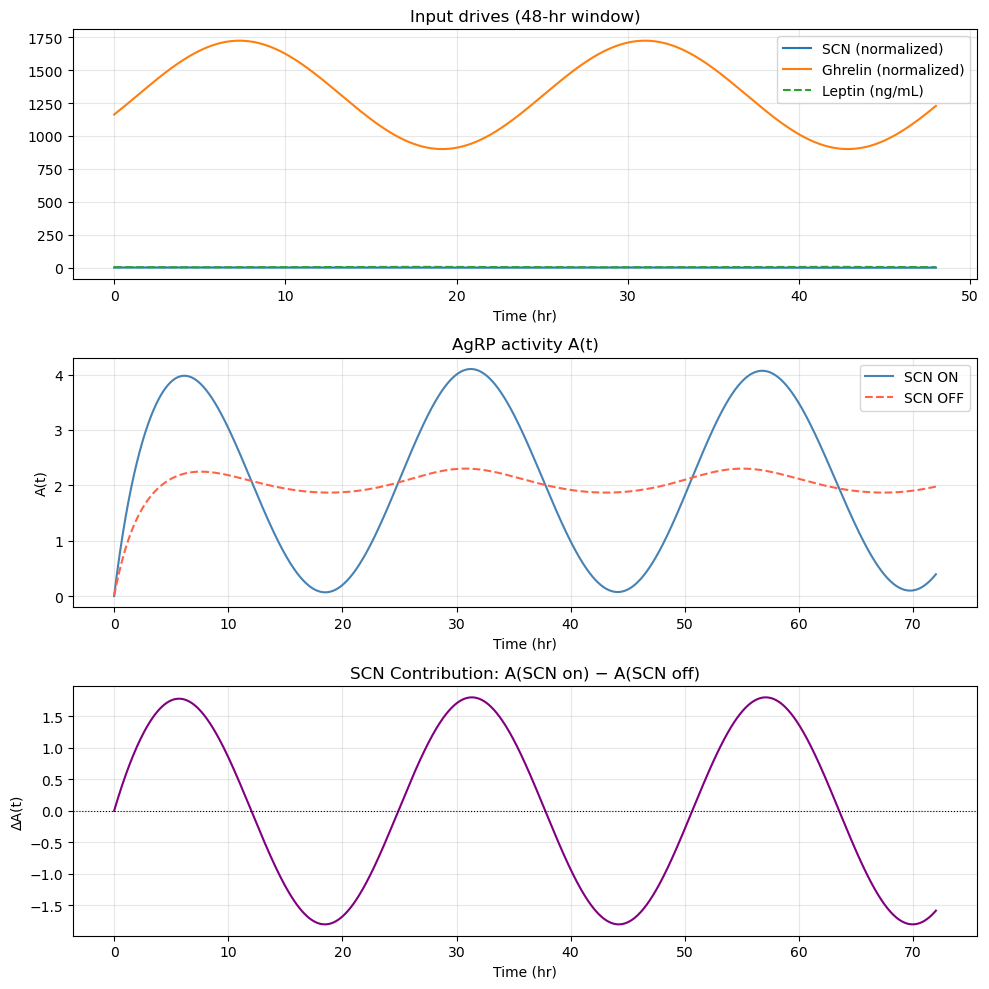

In [46]:
t_on,  A_on  = euler_simulate(scn_on=True)
t_off, A_off = euler_simulate(scn_on=False)

t_probe = np.linspace(0, 48, 1000)
S_plot  = np.array([my.s_norm(t) for t in t_probe])
G_plot  = np.array([my.g_h(t) for t in t_probe])
L_plot  = np.array([my.l(t) for t in t_probe])

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# -- Input drives --
axes[0].plot(t_probe, S_plot, label="SCN (normalized)")
axes[0].plot(t_probe, G_plot, label="Ghrelin (normalized)")
axes[0].plot(t_probe, L_plot, label="Leptin (ng/mL)", linestyle="--")
axes[0].set_title("Input drives (48-hr window)")
axes[0].set_xlabel("Time (hr)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -- AgRP: SCN on vs off --
axes[1].plot(t_on,  A_on,  label="SCN ON",  color="steelblue")
axes[1].plot(t_off, A_off, label="SCN OFF", color="tomato", linestyle="--")
axes[1].set_title("AgRP activity A(t)")
axes[1].set_xlabel("Time (hr)")
axes[1].set_ylabel("A(t)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# -- Difference --
# interpolate to common grid for subtraction
A_diff = A_on - A_off
axes[2].plot(t_on, A_diff, color="purple")
axes[2].axhline(0, color="k", linewidth=0.8, linestyle=":")
axes[2].set_title("SCN Contribution: A(SCN on) − A(SCN off)")
axes[2].set_xlabel("Time (hr)")
axes[2].set_ylabel("ΔA(t)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

RMSE  model(SCN ON)  vs control cosine fit : 0.0458
RMSE  model(SCN OFF) vs caspase cosine fit : 0.1382


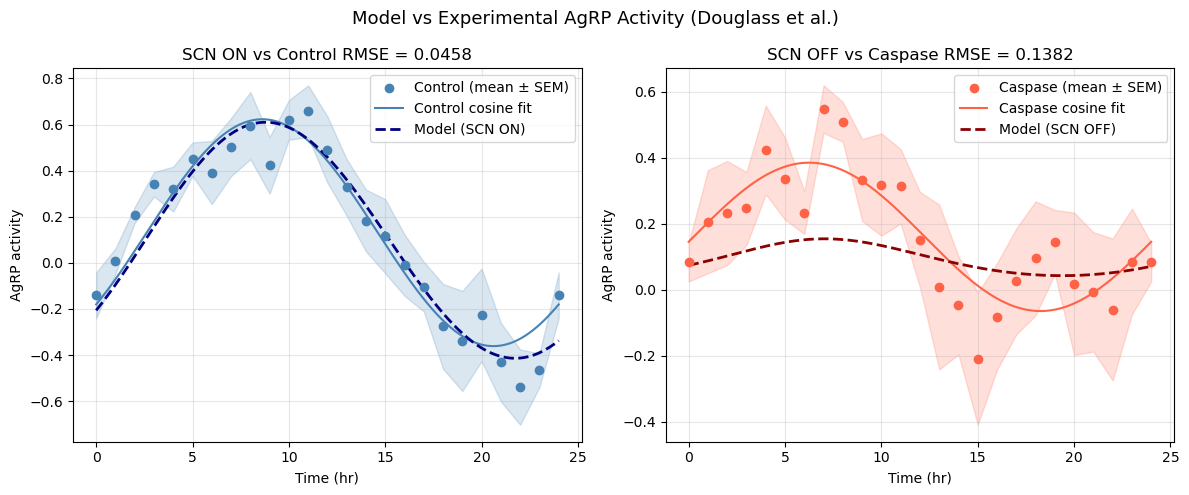

In [52]:
import pandas as pd
from scipy.optimize import curve_fit

# ── Load experimental data ──────────────────────────────────────────────
ctrl_df   = pd.read_csv("../data/AgRP_control-Douglass_2G.csv")
casp_df   = pd.read_csv("../data/AgRP_Caspase-Douglass_5H.csv")

mouse_cols = ["m1", "m2", "m3", "m4", "m5"]

t_ctrl    = ctrl_df["time"].to_numpy(float)
ctrl_mice = ctrl_df[mouse_cols].to_numpy(float)
ctrl_mean = ctrl_mice.mean(axis=1)
ctrl_sem  = ctrl_mice.std(axis=1, ddof=1) / np.sqrt(5)

t_casp    = casp_df["time"].to_numpy(float)
casp_mice = casp_df[mouse_cols].to_numpy(float)
casp_mean = casp_mice.mean(axis=1)
casp_sem  = casp_mice.std(axis=1, ddof=1) / np.sqrt(5)

# ── Cosine fit to data means ─────────────────────────────────────────────
def cos_model(t, A, phi, C):
    return A * np.cos(2 * np.pi * t / 24 + phi) + C

def fit_cosine(t, y):
    p0 = [(y.max() - y.min()) / 2, 0.0, y.mean()]
    popt, _ = curve_fit(cos_model, t, y, p0=p0, maxfev=10000)
    return popt

ctrl_popt = fit_cosine(t_ctrl, ctrl_mean)
casp_popt = fit_cosine(t_casp, casp_mean)

t_smooth = np.linspace(0, 24, 500)
ctrl_cos = cos_model(t_smooth, *ctrl_popt)
casp_cos = cos_model(t_smooth, *casp_popt)

# ── Steady-state model: last 24 h of simulation (48-72 h -> 0-24 h) ──────
mask_on  = (t_on  >= 48) & (t_on  <= 72)
mask_off = (t_off >= 48) & (t_off <= 72)
t_ss_on  = t_on[mask_on]  - 48
A_ss_on  = A_on[mask_on]
t_ss_off = t_off[mask_off] - 48
A_ss_off = A_off[mask_off]

# ── Scale SCN ON to control data; apply same transform to SCN OFF ────────
# Linear map: A_scaled = (A - src_mean) / src_std * tgt_std + tgt_mean
src_mean = A_ss_on.mean()
src_std  = A_ss_on.std()
tgt_mean = ctrl_mean.mean()
tgt_std  = ctrl_mean.std()

A_ss_on_scaled  = (A_ss_on  - src_mean) / src_std * tgt_std + tgt_mean
A_ss_off_scaled = (A_ss_off - src_mean) / src_std * tgt_std + tgt_mean  # same transform

# ── RMSE: scaled model vs data cosine fit ────────────────────────────────
def rmse(pred, obs):
    return np.sqrt(np.mean((pred - obs) ** 2))

rmse_ctrl = rmse(A_ss_on_scaled,  cos_model(t_ss_on,  *ctrl_popt))
rmse_casp = rmse(A_ss_off_scaled, cos_model(t_ss_off, *casp_popt))
print(f"RMSE  model(SCN ON)  vs control cosine fit : {rmse_ctrl:.4f}")
print(f"RMSE  model(SCN OFF) vs caspase cosine fit : {rmse_casp:.4f}")

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: SCN ON vs control
axes[0].fill_between(t_ctrl, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem,
                     alpha=0.2, color="steelblue")
axes[0].scatter(t_ctrl, ctrl_mean, color="steelblue", zorder=3, label="Control (mean ± SEM)")
axes[0].plot(t_smooth, ctrl_cos, color="steelblue", linewidth=1.5, label="Control cosine fit")
axes[0].plot(t_ss_on, A_ss_on_scaled, color="navy", linestyle="--", linewidth=2, label="Model (SCN ON)")
axes[0].set_title(f"SCN ON vs Control RMSE = {rmse_ctrl:.4f}")
axes[0].set_xlabel("Time (hr)")
axes[0].set_ylabel("AgRP activity")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: SCN OFF vs caspase (same scaling as SCN ON)
axes[1].fill_between(t_casp, casp_mean - casp_sem, casp_mean + casp_sem,
                     alpha=0.2, color="tomato")
axes[1].scatter(t_casp, casp_mean, color="tomato", zorder=3, label="Caspase (mean ± SEM)")
axes[1].plot(t_smooth, casp_cos, color="tomato", linewidth=1.5, label="Caspase cosine fit")
axes[1].plot(t_ss_off, A_ss_off_scaled, color="darkred", linestyle="--", linewidth=2, label="Model (SCN OFF)")
axes[1].set_title(f"SCN OFF vs Caspase RMSE = {rmse_casp:.4f}")
axes[1].set_xlabel("Time (hr)")
axes[1].set_ylabel("AgRP activity")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Model vs Experimental AgRP Activity (Douglass et al.)", fontsize=13)
plt.tight_layout()
plt.show()
